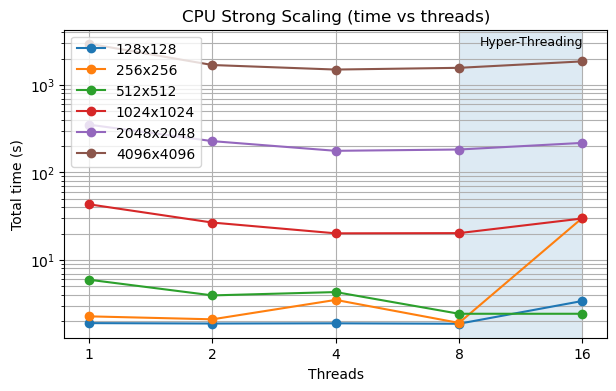

Saved: figures/cpu_strong_scaling_time.png


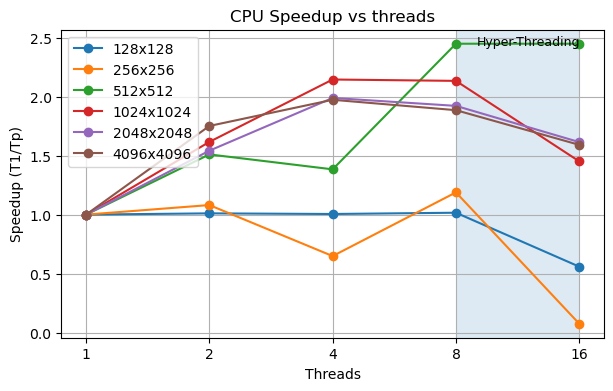

Saved: figures/cpu_speedup.png


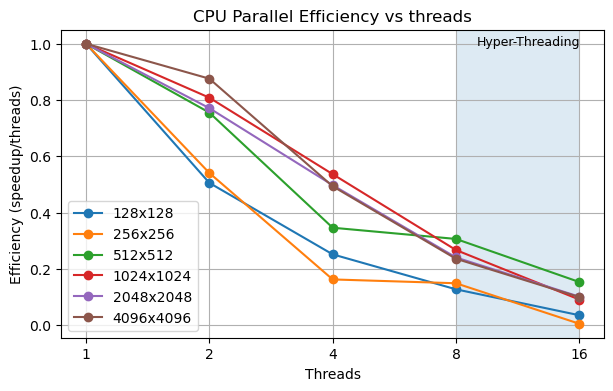

Saved: figures/cpu_efficiency.png


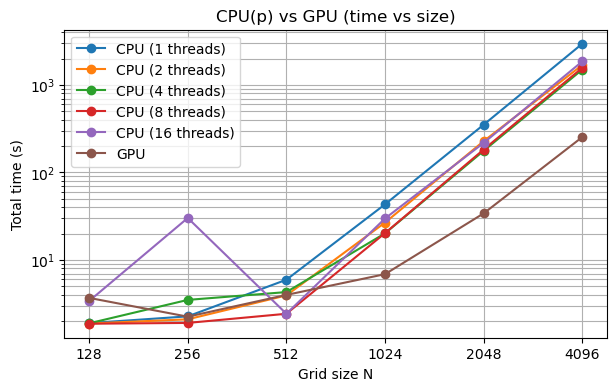

Saved: figures/cpu_vs_gpu_time_multi_threads.png


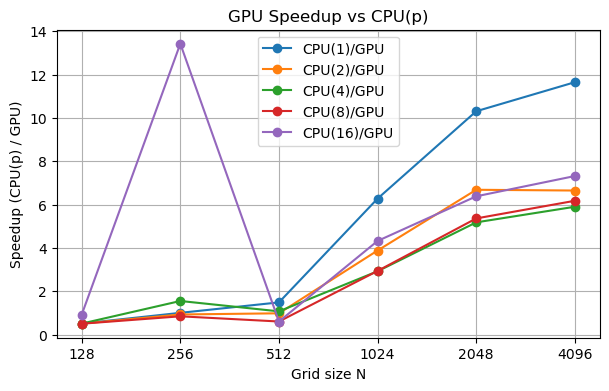

Saved: figures/gpu_speedup_vs_cpu_p.png


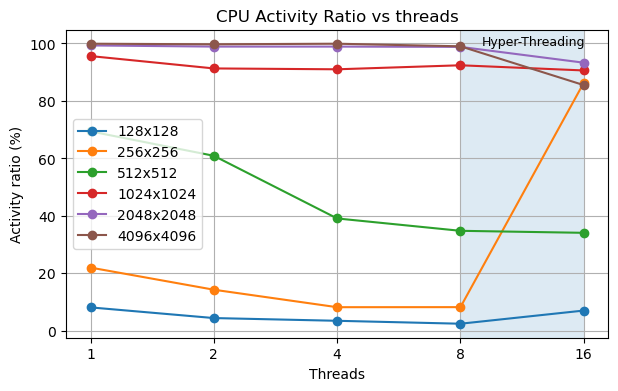

Saved: figures/cpu_activity_ratio.png


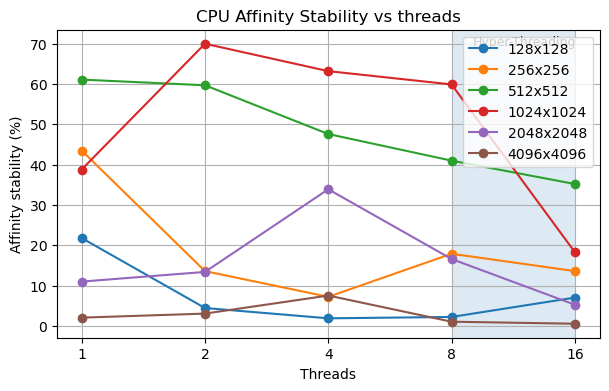

Saved: figures/cpu_affinity_stability.png


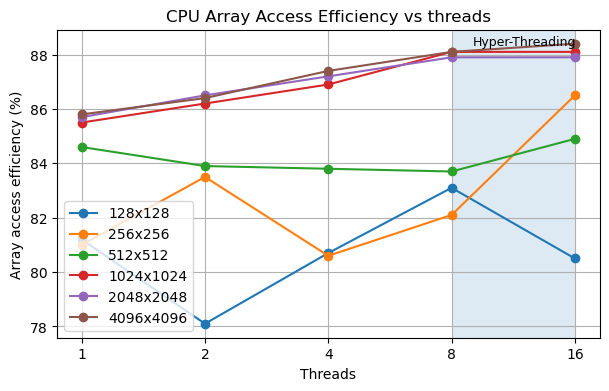

Saved: figures/cpu_array_access_efficiency.png
DONE PNG saved in: figures


In [1]:
# =========================
# FULL CELL: plots + save PNG
# =========================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------- config --------
CSV_PATH = "reportsMaqao.csv"
OUTDIR = "figures"
os.makedirs(OUTDIR, exist_ok=True)

THREAD_TICKS = [1, 2, 4, 8, 16]
SIZE_TICKS   = [128, 256, 512, 1024, 2048, 4096]

# =========================
# LOAD CSV
# =========================
df = pd.read_csv(CSV_PATH)
df["device"] = df["device"].astype(str).str.strip().str.lower()

num_cols = [
    "size","threads",
    "total_time_s","max_thread_active_time_s",
    "activity_ratio_pct","avg_active_threads",
    "affinity_stability_pct","array_access_efficiency_pct"
]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df["size"] = df["size"].astype("Int64")
df["threads"] = df["threads"].astype("Int64")

# =========================
# DERIVED METRICS (CPU)
# =========================
df["speedup"] = np.nan
df["efficiency"] = np.nan

cpu = df[df["device"]=="cpu"].copy()
for N in sorted(cpu["size"].dropna().unique()):
    base = cpu[(cpu["size"]==N) & (cpu["threads"]==1)]["total_time_s"]
    if len(base)==1 and np.isfinite(base.iloc[0]) and base.iloc[0] > 0:
        t1 = float(base.iloc[0])
        mask = (df["device"]=="cpu") & (df["size"]==N)
        df.loc[mask, "speedup"] = t1 / df.loc[mask, "total_time_s"]
        df.loc[mask, "efficiency"] = df.loc[mask, "speedup"] / df.loc[mask, "threads"]

# =========================
# HELPERS
# =========================
def safe_logy():
    ax = plt.gca()
    ys = []
    for line in ax.get_lines():
        ys.extend(line.get_ydata())
    ys = np.array([v for v in ys if np.isfinite(v)])
    if len(ys) > 0 and np.nanmin(ys) > 0:
        plt.yscale("log")

def plot_cpu_metric(col, ylabel, title, filename, logx=True, logy=False):
    plt.figure(figsize=(7,4))
    cpu = df[df["device"]=="cpu"].copy()
    if cpu.empty:
        print(f"[WARN] No CPU data: {title}")
        plt.close()
        return

    for N in sorted(cpu["size"].dropna().unique()):
        sub = cpu[cpu["size"]==N].sort_values("threads")
        plt.plot(sub["threads"], sub[col], marker="o", label=f"{N}x{N}")

    plt.xlabel("Threads")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, which="both")
    plt.legend()

    if logx:
        plt.xscale("log", base=2)
        plt.xticks(THREAD_TICKS, [str(x) for x in THREAD_TICKS])

    # --- highlight hyperthreading zone: 8 -> 16 ---
    ax = plt.gca()
    ax.axvspan(8, 16, alpha=0.15)
    ax.text(9, 0.98, "Hyper-Threading", transform=ax.get_xaxis_transform(),
            va="top", ha="left", fontsize=9)

    if logy:
        safe_logy()

    outpath = os.path.join(OUTDIR, filename)
    plt.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", outpath)

# =========================
# 1) CPU Strong scaling (time)
# =========================
plot_cpu_metric(
    col="total_time_s",
    ylabel="Total time (s)",
    title="CPU Strong Scaling (time vs threads)",
    filename="cpu_strong_scaling_time.png",
    logx=True,
    logy=True
)

# =========================
# 2) CPU Speedup
# =========================
plot_cpu_metric(
    col="speedup",
    ylabel="Speedup (T1/Tp)",
    title="CPU Speedup vs threads",
    filename="cpu_speedup.png",
    logx=True,
    logy=False
)

# =========================
# 3) CPU Efficiency
# =========================
plot_cpu_metric(
    col="efficiency",
    ylabel="Efficiency (speedup/threads)",
    title="CPU Parallel Efficiency vs threads",
    filename="cpu_efficiency.png",
    logx=True,
    logy=False
)

# =========================
# 4) CPU vs GPU (time vs size)  [CPU: 1,2,4,8,16]
# =========================
plt.figure(figsize=(7,4))

sizes = sorted(df["size"].dropna().unique())
gpu_t = df[df["device"]=="gpu"].set_index("size")["total_time_s"]

for p in THREAD_TICKS:
    cpu_tp = df[(df["device"]=="cpu") & (df["threads"]==p)].set_index("size")["total_time_s"]
    plt.plot(sizes, [cpu_tp.get(s, np.nan) for s in sizes], marker="o", label=f"CPU ({p} threads)")

plt.plot(sizes, [gpu_t.get(s, np.nan) for s in sizes], marker="o", label="GPU")

plt.xlabel("Grid size N")
plt.ylabel("Total time (s)")
plt.title("CPU(p) vs GPU (time vs size)")
plt.grid(True, which="both")
plt.legend()

plt.xscale("log", base=2)
plt.xticks(SIZE_TICKS, [str(x) for x in SIZE_TICKS])
safe_logy()

outpath = os.path.join(OUTDIR, "cpu_vs_gpu_time_multi_threads.png")
plt.savefig(outpath, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", outpath)

# =========================
# 5) GPU speedup vs CPU(p)  [p = 1,2,4,8,16]
# =========================
plt.figure(figsize=(7,4))

gpu_t = df[df["device"]=="gpu"].set_index("size")["total_time_s"]

for p in THREAD_TICKS:
    cpu_tp = df[(df["device"]=="cpu") & (df["threads"]==p)].set_index("size")["total_time_s"]

    speedup_p = []
    for s in sizes:
        c = cpu_tp.get(s, np.nan)
        g = gpu_t.get(s, np.nan)
        speedup_p.append(c/g if (np.isfinite(c) and np.isfinite(g) and g>0) else np.nan)

    plt.plot(sizes, speedup_p, marker="o", label=f"CPU({p})/GPU")

plt.xlabel("Grid size N")
plt.ylabel("Speedup (CPU(p) / GPU)")
plt.title("GPU Speedup vs CPU(p)")
plt.grid(True, which="both")
plt.legend()

plt.xscale("log", base=2)
plt.xticks(SIZE_TICKS, [str(x) for x in SIZE_TICKS])

outpath = os.path.join(OUTDIR, "gpu_speedup_vs_cpu_p.png")
plt.savefig(outpath, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", outpath)

# =========================
# 6) Activity ratio
# =========================
plot_cpu_metric(
    col="activity_ratio_pct",
    ylabel="Activity ratio (%)",
    title="CPU Activity Ratio vs threads",
    filename="cpu_activity_ratio.png",
    logx=True,
    logy=False
)

# =========================
# 7) Affinity stability
# =========================
plot_cpu_metric(
    col="affinity_stability_pct",
    ylabel="Affinity stability (%)",
    title="CPU Affinity Stability vs threads",
    filename="cpu_affinity_stability.png",
    logx=True,
    logy=False
)

# =========================
# 8) Array access efficiency
# =========================
plot_cpu_metric(
    col="array_access_efficiency_pct",
    ylabel="Array access efficiency (%)",
    title="CPU Array Access Efficiency vs threads",
    filename="cpu_array_access_efficiency.png",
    logx=True,
    logy=False
)

print("DONE PNG saved in:", OUTDIR)